In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
import xgboost as xgb
import pickle

trans = pd.read_csv('/kaggle/input/competitions/ieee-fraud-detection/train_transaction.csv')
identity = pd.read_csv('/kaggle/input/competitions/ieee-fraud-detection/train_identity.csv')

df = trans.merge(identity, on='TransactionID', how='left')

missing = (df.isnull().sum() / len(df) * 100)
cols_to_drop = missing[missing > 90].index.tolist()
df = df.drop(columns=cols_to_drop)
numerical_cols = df.select_dtypes(include=[np.number]).columns
df[numerical_cols] = df[numerical_cols].fillna(df[numerical_cols].median())
categorical_cols = df.select_dtypes(include=['object']).columns
df[categorical_cols] = df[categorical_cols].fillna('Unknown')
df = df.copy()

df['hour'] = (df['TransactionDT'] // 3600) % 24
df['day'] = (df['TransactionDT'] // (3600 * 24)) % 7
df['is_late_night'] = df['hour'].apply(lambda x: 1 if 1 <= x <= 9 else 0)
df['log_amount'] = np.log1p(df['TransactionAmt'])
df['is_card_probe'] = (df['TransactionAmt'] < 1).astype(int)
df['is_threshold_avoid'] = ((df['TransactionAmt'] >= 500) & (df['TransactionAmt'] < 1000)).astype(int)
df['has_identity'] = df['DeviceType'].apply(lambda x: 0 if x == 'Unknown' else 1)
df['is_mobile'] = df['DeviceType'].apply(lambda x: 1 if x == 'mobile' else 0)

card_counts = df.groupby('card1')['TransactionAmt'].count().reset_index()
card_counts.columns = ['card1', 'card1_count']
df = df.merge(card_counts, on='card1', how='left')

card_mean = df.groupby('card1')['TransactionAmt'].mean().reset_index()
card_mean.columns = ['card1', 'card1_mean_amt']
df = df.merge(card_mean, on='card1', how='left')

df['amt_deviation'] = abs(df['TransactionAmt'] - df['card1_mean_amt'])
df['amt_deviation_ratio'] = df['amt_deviation'] / (df['card1_mean_amt'] + 1)

free_emails = ['gmail.com', 'yahoo.com', 'hotmail.com', 'outlook.com', 'aol.com', 'mail.com']
df['is_free_email'] = df['P_emaildomain'].apply(lambda x: 1 if x in free_emails else 0)
df['email_match'] = (df['P_emaildomain'] == df['R_emaildomain']).astype(int)

def fraud_rate_encode(df, col):
    fraud_rates = df.groupby(col)['isFraud'].mean()
    return df[col].map(fraud_rates)

df['product_fraud_rate'] = fraud_rate_encode(df, 'ProductCD')
df['card4_fraud_rate'] = fraud_rate_encode(df, 'card4')
df['card6_fraud_rate'] = fraud_rate_encode(df, 'card6')

drop_cols = ['TransactionID', 'isFraud', 'TransactionDT',
             'ProductCD', 'card4', 'card6',
             'P_emaildomain', 'R_emaildomain', 'DeviceType']
drop_cols = [c for c in drop_cols if c in df.columns]
string_cols = df.drop(columns=drop_cols).select_dtypes(include=['object']).columns.tolist()

X = df.drop(columns=drop_cols + string_cols)
y = df['isFraud']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print("Ready!")
print("Training set:", X_train.shape)
print("Test set:", X_test.shape)

Ready!
Training set: (472432, 407)
Test set: (118108, 407)


In [2]:
scale = (y_train == 0).sum() / (y_train == 1).sum()

best_model = xgb.XGBClassifier(
    n_estimators=500,
    max_depth=8,
    learning_rate=0.2,
    subsample=0.9,
    colsample_bytree=0.8,
    scale_pos_weight=scale,
    random_state=42,
    tree_method='hist',
    device='cuda',
    eval_metric='aucpr'
)

print("Training...")
best_model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=100)
print("Done!")

Training...
[0]	validation_0-aucpr:0.37366
[100]	validation_0-aucpr:0.72615
[200]	validation_0-aucpr:0.77933
[300]	validation_0-aucpr:0.79934
[400]	validation_0-aucpr:0.81476
[499]	validation_0-aucpr:0.82392
Done!


SHAP values calculated!
Shape: (500, 407)


NameError: name 'plt' is not defined

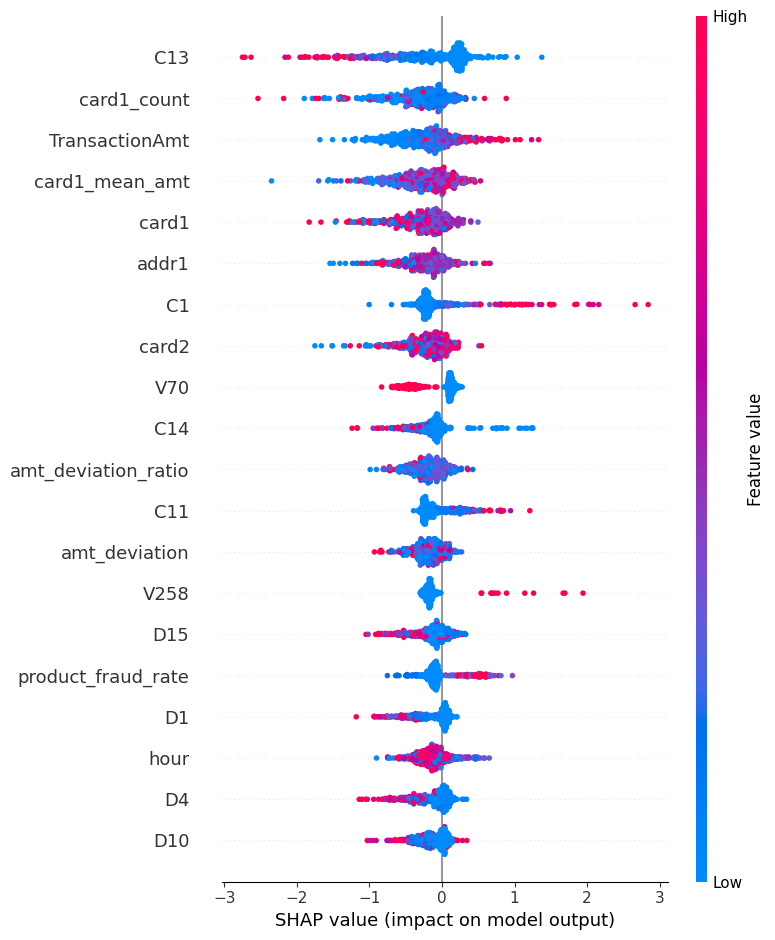

In [3]:
import shap

# create explainer using the trained model
explainer = shap.TreeExplainer(best_model)

# calculate SHAP values on a sample of test data
# we use 500 rows - enough to see patterns without taking forever
X_sample = X_test.iloc[:500]
shap_values = explainer.shap_values(X_sample)

print("SHAP values calculated!")
print(f"Shape: {shap_values.shape}")

# summary plot - shows which features matter most overall
shap.summary_plot(shap_values, X_sample, max_display=20, show=False)
plt.savefig('/kaggle/working/shap_summary.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved!")

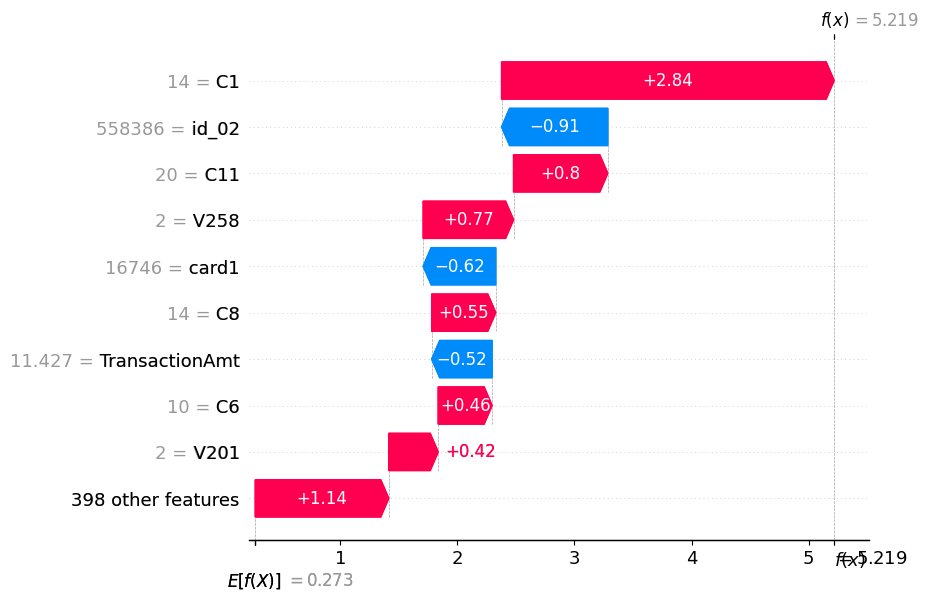

Saved!


In [5]:
import matplotlib.pyplot as plt

# explain one specific transaction
fraud_idx = y_test[y_test == 1].index[0]
fraud_pos = X_test.index.get_loc(fraud_idx)

shap.waterfall_plot(
    shap.Explanation(
        values=shap_values[fraud_pos],
        base_values=explainer.expected_value,
        data=X_sample.iloc[fraud_pos],
        feature_names=X_test.columns.tolist()
    ),
    max_display=10,
    show=False
)
plt.savefig('/kaggle/working/shap_single.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved!")

In [6]:
import pickle

shap_data = {
    'explainer': explainer,
    'feature_columns': list(X_train.columns),
    'expected_value': explainer.expected_value
}

with open('/kaggle/working/shap_explainer.pkl', 'wb') as f:
    pickle.dump(shap_data, f)

# also save the final model with threshold
model_data = {
    'model': best_model,
    'threshold': 0.7015,
    'feature_columns': list(X_train.columns)
}

with open('/kaggle/working/final_model.pkl', 'wb') as f:
    pickle.dump(model_data, f)

print("Both saved!")
print("Ready to build the LLM demo")

Both saved!
Ready to build the LLM demo
